In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import backend as K
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

2026-01-10 21:43:44.495333: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# GPU training

# # --- GPU + Mixed Precision Setup (start cell) ---
# from tensorflow.keras import mixed_precision

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# gpus = tf.config.list_physical_devices('GPU')
# if gpus:
#     print(f"GPU detected: {gpus[0].name}")
# else:
#     print("GPU NOT detected — TensorFlow will run on CPU")

# mixed_precision.set_global_policy("mixed_float16")
# print("Mixed precision enabled (mixed_float16)")

# print(f"TensorFlow version: {tf.__version__}")
# print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
# print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

GPU detected: /physical_device:GPU:0
Mixed precision enabled (mixed_float16)
TensorFlow version: 2.20.0
Compute dtype: float16
Variable dtype: float32


In [3]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [4]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [5]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [6]:
X_train_lstm = X_train.squeeze(axis=-1)  # Usuń ostatni wymiar (kanał)
X_test_lstm = X_test.squeeze(axis=-1)
print(f"LSTM input shape - Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")

LSTM input shape - Train: (11980, 150, 150), Test: (2995, 150, 150)


In [7]:
input_shape = (150, 150)
input_layer = Input(shape=input_shape)

# LSTM Layers (Bidirectional)
lstm_layer = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(input_layer)
lstm_layer = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(lstm_layer)

# Attention Mechanism
attention = layers.Dense(1, activation='tanh')(lstm_layer)
attention = layers.Flatten()(attention)
attention = layers.Activation('softmax')(attention)
attention = layers.RepeatVector(128)(attention)
attention = layers.Permute((2, 1))(attention)
attention = layers.Multiply()([lstm_layer, attention])
attention = layers.Lambda(lambda x: K.sum(x, axis=1))(attention)

# Convolutional Layer
conv_layer = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(lstm_layer)

# Dense Layers
dense_layer = layers.Dense(64, activation='relu')(conv_layer)
dropout_layer = layers.Dropout(0.2)(dense_layer)
dense_layer = layers.Dense(32, activation='relu')(dropout_layer)
dropout_layer = layers.Dropout(0.2)(dense_layer)
global_avg_pool = layers.GlobalAveragePooling1D()(dense_layer)

# Output Layer
merged = layers.Concatenate()([attention, global_avg_pool])
output_layer = layers.Dense(10, activation='softmax')(merged)

model = Model(inputs=input_layer, outputs=output_layer)

I0000 00:00:1768077985.953531   23426 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 150, 256)  │    285,696 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 150, 128)  │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 150, 1)    │        129 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 150)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150)       │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 150, 32)   │     20,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 150)  │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 150, 64)   │      2,112 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 150, 128)  │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 150, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 150, 128)  │          0 │ bidirectional_1[… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 150, 32)   │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dense_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      1,610 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 476,491 (1.82 MB)

 Trainable params: 476,491 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train_lstm, Y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

2026-01-10 21:46:53.462418: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.
2026-01-10 21:46:54.564714: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 862560000 exceeds 10% of free system memory.


Epoch 1/30


2026-01-10 21:47:02.004093: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


300/300 ━━━━━━━━━━━━━━━━━━━━ 57s 77ms/step - accuracy: 0.3558 - loss: 1.7680 - val_accuracy: 0.4599 - val_loss: 1.5083
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.4903 - loss: 1.4184 - val_accuracy: 0.5129 - val_loss: 1.3549
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step - accuracy: 0.5453 - loss: 1.2623 - val_accuracy: 0.5509 - val_loss: 1.2570
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - accuracy: 0.5958 - loss: 1.1233 - val_accuracy: 0.5367 - val_loss: 1.2859
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - accuracy: 0.6278 - loss: 1.0330 - val_accuracy: 0.5710 - val_loss: 1.2069
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 85ms/step - accuracy: 0.6689 - loss: 0.9313 - val_accuracy: 0.5818 - val_loss: 1.1771
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.7090 - loss: 0.8250 - val_accuracy: 0.6189 - val_loss: 1.0939
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step - accuracy: 0.7362 - loss: 0.7557 - val_accurac

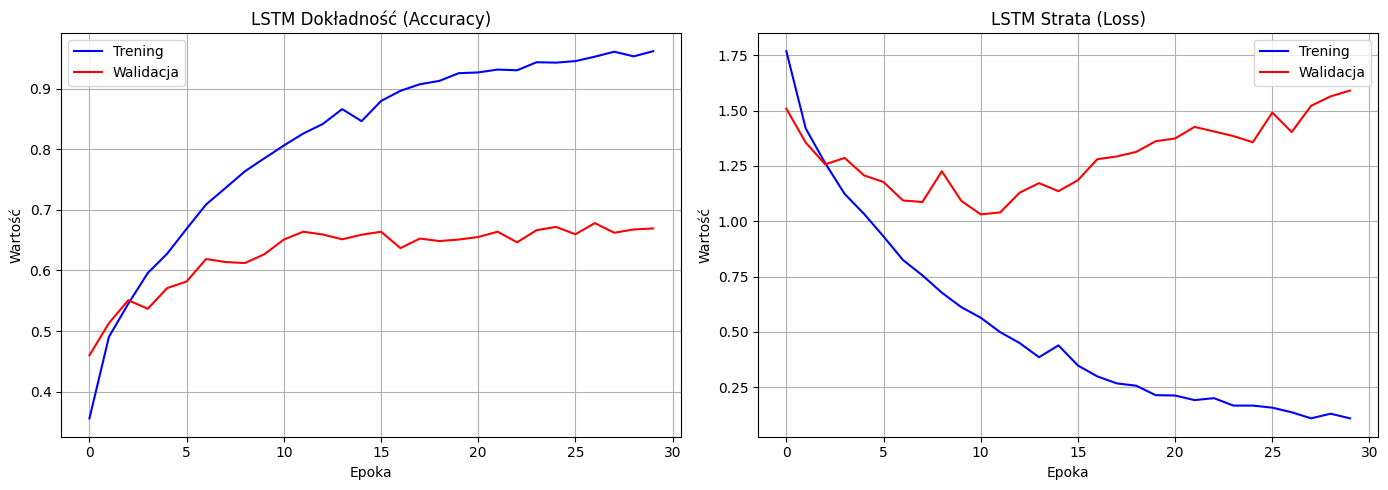

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('LSTM Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('LSTM Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(X_test_lstm, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6935 - loss: 1.4448

Dokładność na zbiorze testowym: 69.35%
Strata na zbiorze testowym: 1.4448


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


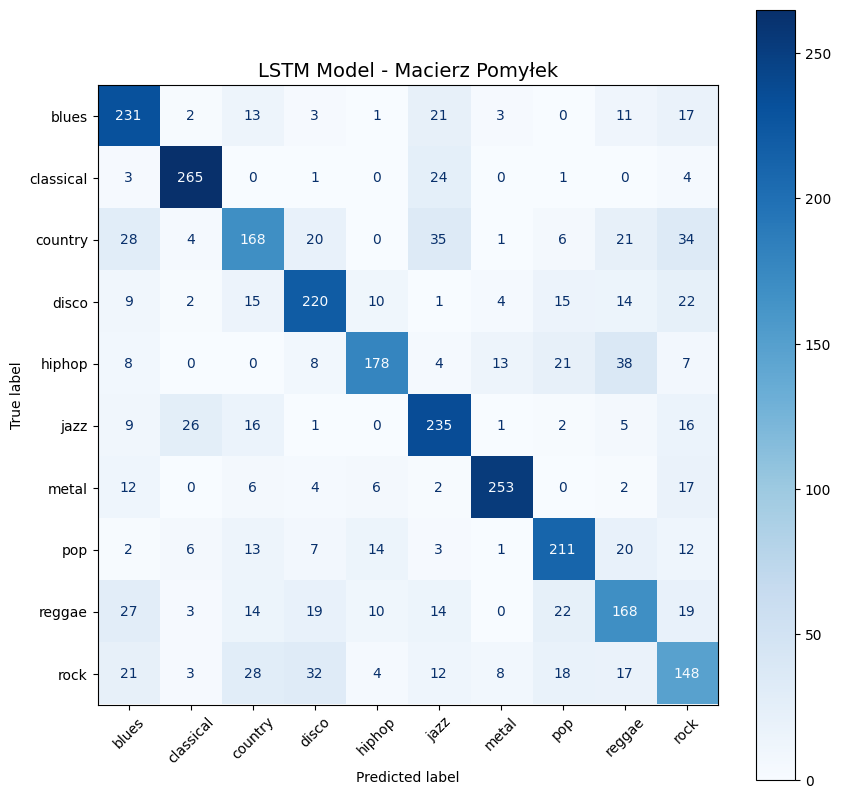


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.66      0.76      0.71       302
   classical       0.85      0.89      0.87       298
     country       0.62      0.53      0.57       317
       disco       0.70      0.71      0.70       312
      hiphop       0.80      0.64      0.71       277
        jazz       0.67      0.76      0.71       311
       metal       0.89      0.84      0.86       302
         pop       0.71      0.73      0.72       289
      reggae       0.57      0.57      0.57       296
        rock       0.50      0.51      0.50       291

    accuracy                           0.69      2995
   macro avg       0.70      0.69      0.69      2995
weighted avg       0.70      0.69      0.69      2995



In [13]:
Y_pred_proba = model.predict(X_test_lstm)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(10, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('LSTM Model - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [ ]:
model.save('../models/LSTM.keras')
print("Model zapisany jako: ../models/LSTM.keras")

Model zapisany jako: ../models/LSTM.keras


: 